# 7 — Wet-Day Threshold Analysis

**Goal:** Determine the optimal wet-day threshold per grid cell for separating
the zero-inflated dry-period spike from the continuous Pearson III wet distribution.

The 7-day mean precipitation at each cell follows a mixture:
- **Dry component**: point mass near zero (true dry + trace precip)
- **Wet component**: continuous right-skewed distribution ≈ Pearson III

Finding T* per cell enables clean 4-output ML targets:
> **POP** (P(precip > T*)) · **P3 skewness** · **P3 location** · **P3 scale**

**Candidate thresholds**: 0.01, 0.05, 0.1, 0.2, 0.5, 1.0 mm/day  
**Selection criterion**: minimise KS statistic of P3 fit (subject to n ≥ 30)

In [1]:
import os, sys
os.environ['PYDEVD_DISABLE_FILE_VALIDATION'] = '1'
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
import yaml, warnings
warnings.filterwarnings('ignore')

from src.analysis.threshold import (
    fit_optimal_thresholds, city_threshold_analysis, THRESHOLDS
)

with open('../config/config.yaml') as f:
    config = yaml.safe_load(f)

# Representative cities (name, lat, lon)
CITIES = {
    'Seattle, WA':     (47.6, -122.3),
    'Los Angeles, CA': (34.1, -118.2),
    'Phoenix, AZ':     (33.4, -112.1),
    'Denver, CO':      (39.7, -104.9),
    'Kansas City, MO': (39.1,  -94.6),
    'New Orleans, LA': (30.0,  -90.1),
    'Miami, FL':       (25.8,  -80.2),
    'New York, NY':    (40.7,  -74.0),
}

THRESH_COLORS = ['#d73027','#fc8d59','#fee090','#91bfdb','#4575b4','#313695']
print('Setup complete. Thresholds:', THRESHOLDS)

Setup complete. Thresholds: [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]


## 1. City-level distribution exploration

For each city: histogram of ALL 7-day mean values, with candidate thresholds
marked. The zero-spike vs continuous-distribution boundary is visible here.

In [2]:
# Run city analysis (fast — single cell per city)
city_data = {}
for city, (lat, lon) in CITIES.items():
    city_data[city] = city_threshold_analysis(config, lat, lon)
    r = city_data[city]
    best = min([x for x in r['results'] if x.get('valid')],
               key=lambda x: x['ks_stat'], default=None)
    best_T = best['threshold'] if best else 'N/A'
    print(f"{city:22s}: n={r['n_total']}  "
          f"frac_zero={100*(r['values']==0).mean():.1f}%  "
          f"frac<0.1={100*(r['values']<0.1).mean():.1f}%  "
          f"best_T={best_T} mm/d")

Seattle, WA           : n=7292  frac_zero=9.6%  frac<0.1=18.0%  best_T=0.1 mm/d


Los Angeles, CA       : n=7292  frac_zero=54.0%  frac<0.1=66.2%  best_T=0.1 mm/d


Phoenix, AZ           : n=7292  frac_zero=52.8%  frac<0.1=65.3%  best_T=0.5 mm/d


Denver, CO            : n=7292  frac_zero=13.6%  frac<0.1=28.6%  best_T=1.0 mm/d


Kansas City, MO       : n=7292  frac_zero=9.9%  frac<0.1=20.3%  best_T=0.1 mm/d


New Orleans, LA       : n=7292  frac_zero=7.2%  frac<0.1=15.4%  best_T=0.2 mm/d


Miami, FL             : n=7292  frac_zero=4.7%  frac<0.1=12.6%  best_T=1.0 mm/d


New York, NY          : n=7292  frac_zero=5.0%  frac<0.1=10.4%  best_T=1.0 mm/d


Global max density: 543.7   log y-axis top: 861.8


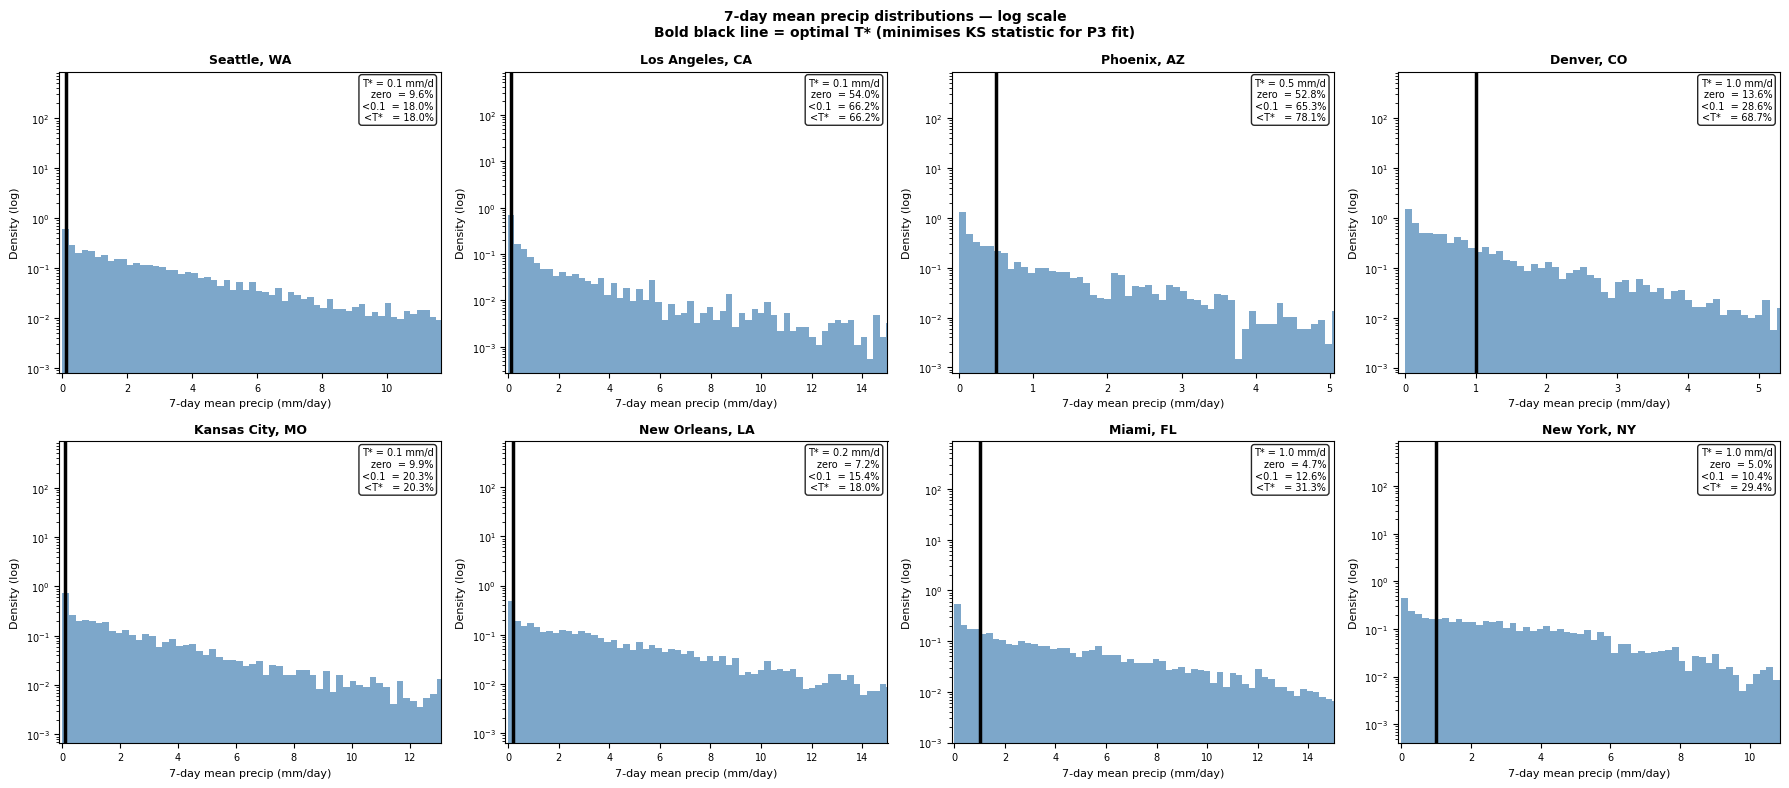

Saved: threshold_city_histograms.png


In [3]:
# ── Shared y-axis limit (data-driven) ──────────────────────────────────────
_max_density = 0
for r in city_data.values():
    vals = r['values']
    bins_tmp = np.concatenate([[0], np.linspace(0.001, min(np.percentile(vals[vals>0], 99), 20), 80)])
    h, _ = np.histogram(vals, bins=bins_tmp, density=True)
    _max_density = max(_max_density, h.max())
ymax_log = 10 ** (np.log10(_max_density) + 0.2)
print(f'Global max density: {_max_density:.1f}   log y-axis top: {ymax_log:.1f}')

# ── LOG-SCALE figure ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for ax, (city, r) in zip(axes, city_data.items()):
    vals = r['values']
    bins = np.concatenate([[0], np.linspace(0.001, min(np.percentile(vals[vals>0], 99), 20), 80)])
    ax.hist(vals, bins=bins, color='steelblue', alpha=0.7, density=True)

    valid = [x for x in r['results'] if x.get('valid')]
    best_T = None
    if valid:
        best  = min(valid, key=lambda x: x['ks_stat'])
        best_T = best['threshold']
        ax.axvline(best_T, color='k', lw=2.5, ls='-', label=f'T* = {best_T} mm/d')

    ax.set_yscale('log')
    ax.set_ylim(top=ymax_log)
    ax.set_xlim(-0.1, min(np.percentile(vals[vals>0], 97), 15) if (vals>0).any() else 5)
    ax.set_xlabel('7-day mean precip (mm/day)', fontsize=8)
    ax.set_ylabel('Density (log)', fontsize=8)
    ax.set_title(city, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)

    frac0  = (vals == 0).mean()
    frac01 = (vals < 0.1).mean()
    frac_T = (vals < best_T).mean() if best_T is not None else float('nan')
    T_str  = f'{best_T} mm/d' if best_T is not None else 'N/A'
    ax.text(0.98, 0.98,
            f'T* = {T_str}\nzero  = {100*frac0:.1f}%\n<0.1  = {100*frac01:.1f}%\n<T*   = {100*frac_T:.1f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

fig.suptitle('7-day mean precip distributions — log scale\n'
             'Bold black line = optimal T* (minimises KS statistic for P3 fit)',
             fontsize=10, fontweight='bold')
fig.tight_layout()
plt.savefig('../output/unconditional/figures/threshold_city_histograms.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: threshold_city_histograms.png')

Max wet-period density: 2.110   linear y-axis top: 2.426


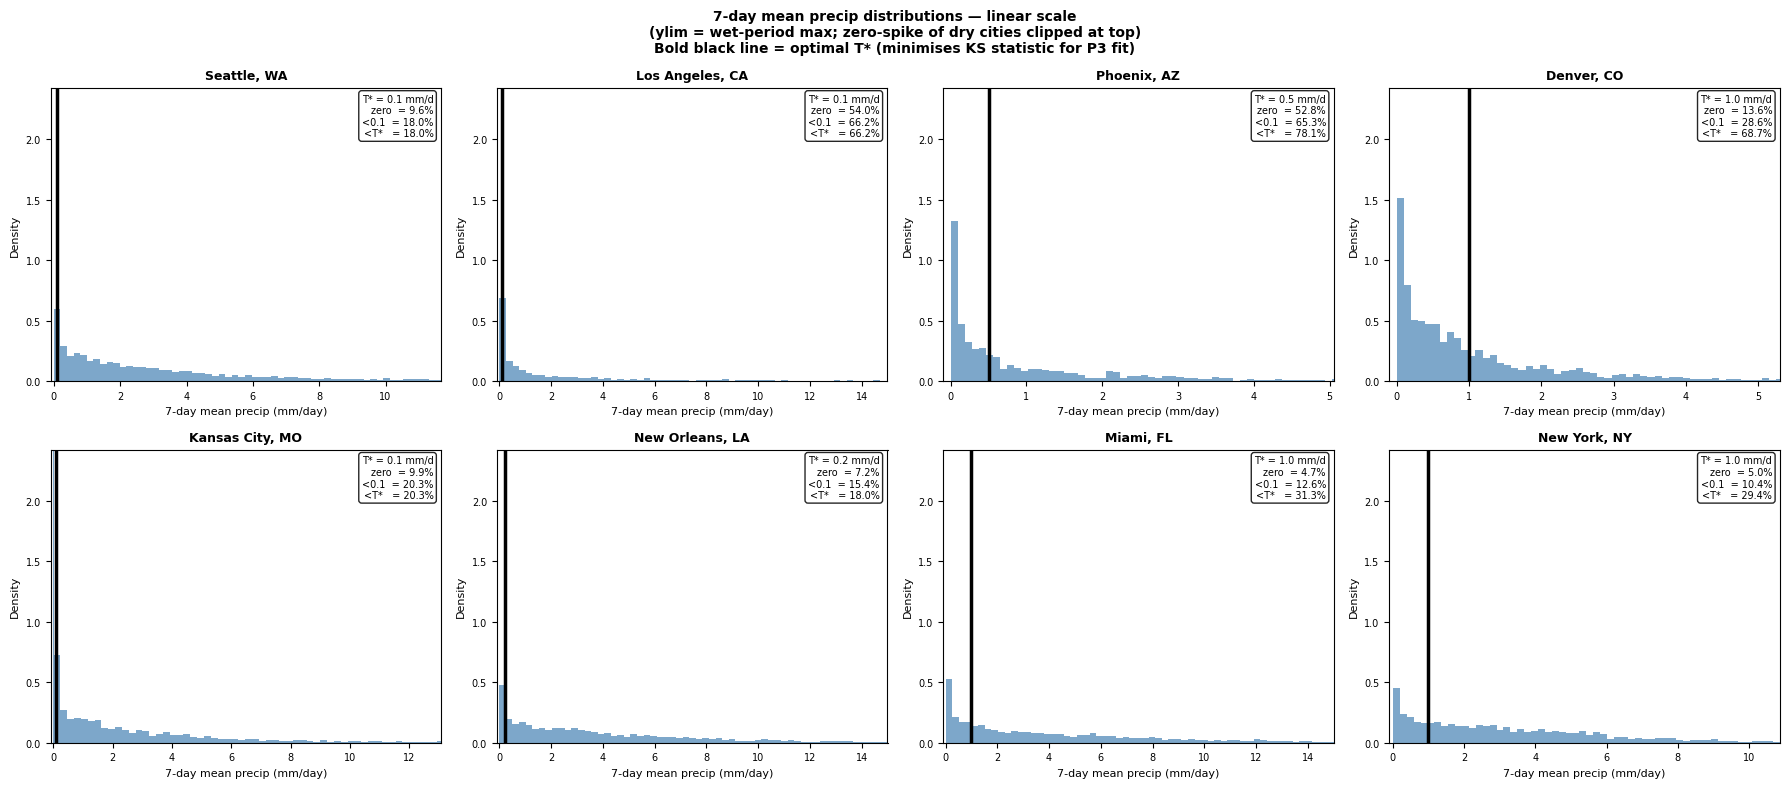

Saved: threshold_city_histograms_linear.png


In [4]:
# ── LINEAR-SCALE figure ───────────────────────────────────────────────────────
# ylim driven by wet-period max density (values > 0.01) so the zero-spike of
# dry cities is clipped at the top rather than compressing the wet distribution.
_max_wet = 0
for r in city_data.values():
    vals = r['values']
    wet  = vals[vals > 0.01]
    if len(wet) < 30:
        continue
    bins_tmp = np.linspace(0.01, min(np.percentile(wet, 99), 20), 60)
    if len(bins_tmp) > 1:
        h, _ = np.histogram(wet, bins=bins_tmp, density=True)
        _max_wet = max(_max_wet, h.max())
ymax_lin = _max_wet * 1.15
print(f'Max wet-period density: {_max_wet:.3f}   linear y-axis top: {ymax_lin:.3f}')

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for ax, (city, r) in zip(axes, city_data.items()):
    vals = r['values']
    bins = np.concatenate([[0], np.linspace(0.001, min(np.percentile(vals[vals>0], 99), 20), 80)])
    ax.hist(vals, bins=bins, color='steelblue', alpha=0.7, density=True)

    valid = [x for x in r['results'] if x.get('valid')]
    best_T = None
    if valid:
        best   = min(valid, key=lambda x: x['ks_stat'])
        best_T = best['threshold']
        ax.axvline(best_T, color='k', lw=2.5, ls='-', label=f'T* = {best_T} mm/d')

    ax.set_ylim(0, ymax_lin)   # zero-spike of dry cities clipped — intentional
    ax.set_xlim(-0.1, min(np.percentile(vals[vals>0], 97), 15) if (vals>0).any() else 5)
    ax.set_xlabel('7-day mean precip (mm/day)', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.set_title(city, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)

    frac0  = (vals == 0).mean()
    frac01 = (vals < 0.1).mean()
    frac_T = (vals < best_T).mean() if best_T is not None else float('nan')
    T_str  = f'{best_T} mm/d' if best_T is not None else 'N/A'
    ax.text(0.98, 0.98,
            f'T* = {T_str}\nzero  = {100*frac0:.1f}%\n<0.1  = {100*frac01:.1f}%\n<T*   = {100*frac_T:.1f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

fig.suptitle('7-day mean precip distributions — linear scale\n'
             '(ylim = wet-period max; zero-spike of dry cities clipped at top)\n'
             'Bold black line = optimal T* (minimises KS statistic for P3 fit)',
             fontsize=10, fontweight='bold')
fig.tight_layout()
plt.savefig('../output/unconditional/figures/threshold_city_histograms_linear.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: threshold_city_histograms_linear.png')

## 2. KS statistic vs threshold — how fit quality changes

For each city: KS statistic (lower = better P3 fit) and POP as a function
of threshold. The optimal T* is the threshold minimising KS.

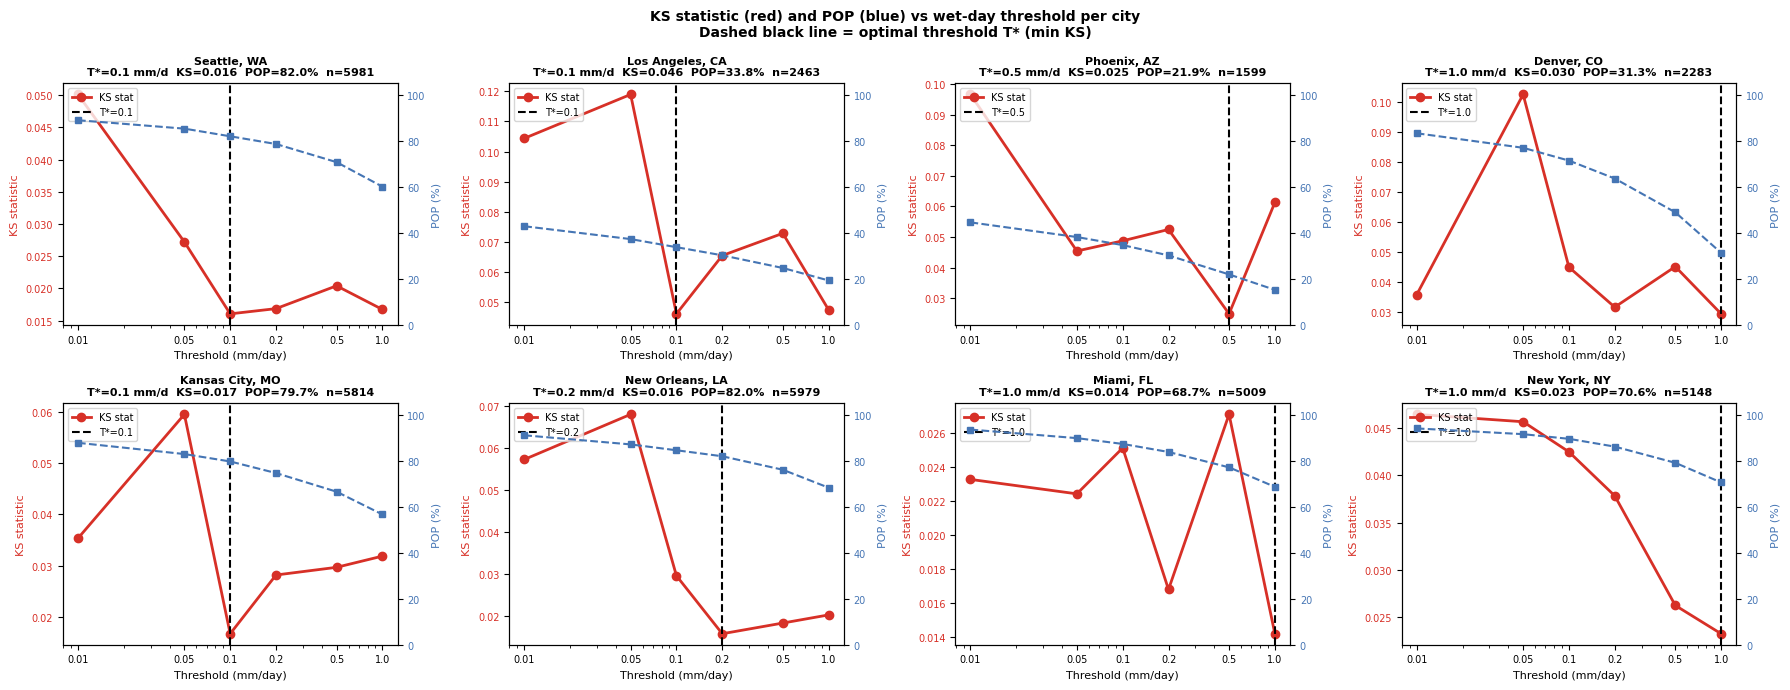

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.ravel()

for ax, (city, r) in zip(axes, city_data.items()):
    valid = [x for x in r['results'] if x.get('valid')]
    if not valid:
        ax.set_title(f'{city}\n(insufficient data)', fontsize=8)
        continue

    Ts   = [x['threshold'] for x in valid]
    ks   = [x['ks_stat']   for x in valid]
    pop  = [x['pop']       for x in valid]
    nw   = [x['n_wetdays'] for x in valid]

    best_idx = int(np.argmin(ks))
    best_T   = Ts[best_idx]

    # KS statistic (left axis)
    ax.plot(Ts, ks, 'o-', color='#d73027', lw=2, ms=6, label='KS stat')
    ax.axvline(best_T, color='k', lw=1.5, ls='--', label=f'T*={best_T}')
    ax.set_xlabel('Threshold (mm/day)', fontsize=8)
    ax.set_ylabel('KS statistic', fontsize=8, color='#d73027')
    ax.tick_params(axis='y', labelcolor='#d73027', labelsize=7)
    ax.set_xscale('log')
    ax.set_xticks(THRESHOLDS)
    ax.set_xticklabels([str(t) for t in THRESHOLDS], fontsize=7)

    # POP (right axis)
    ax2 = ax.twinx()
    ax2.plot(Ts, [p*100 for p in pop], 's--', color='#4575b4', lw=1.5, ms=5, label='POP %')
    ax2.set_ylabel('POP (%)', fontsize=8, color='#4575b4')
    ax2.tick_params(axis='y', labelcolor='#4575b4', labelsize=7)
    ax2.set_ylim(0, 105)

    ax.set_title(f'{city}\nT*={best_T} mm/d  KS={min(ks):.3f}  '
                 f'POP={100*pop[best_idx]:.1f}%  n={nw[best_idx]}',
                 fontsize=8, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')

fig.suptitle('KS statistic (red) and POP (blue) vs wet-day threshold per city\n'
             'Dashed black line = optimal threshold T* (min KS)',
             fontsize=10, fontweight='bold')
fig.tight_layout()
plt.savefig('../output/unconditional/figures/threshold_city_ks_vs_threshold.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 3. Fit optimal thresholds across all CPC land cells

This runs in parallel (~5–10 min). Cached to NetCDF — subsequent runs load instantly.

In [6]:
ds_thresh = fit_optimal_thresholds(config, workers=16, overwrite=False)
print(ds_thresh)

# Summary: which threshold wins most often?
T_vals = ds_thresh['optimal_threshold'].values.ravel()
T_valid = T_vals[np.isfinite(T_vals)]
unique, counts = np.unique(T_valid, return_counts=True)
print('\nOptimal threshold distribution across CONUS cells:')
for T, n in zip(unique, counts):
    print(f'  T={T:5.2f} mm/d: {n:6d} cells  ({100*n/len(T_valid):.1f}%)')

[threshold] Loading cached result: cpc_optimal_threshold.nc
<xarray.Dataset> Size: 2MB
Dimensions:            (lat: 104, lon: 236)
Coordinates:
  * lat                (lat) float32 416B 24.12 24.38 24.62 ... 49.62 49.88
  * lon                (lon) float32 944B -124.9 -124.6 -124.4 ... -66.38 -66.12
Data variables:
    optimal_threshold  (lat, lon) float64 196kB ...
    pop                (lat, lon) float64 196kB ...
    p3_skew            (lat, lon) float64 196kB ...
    p3_loc             (lat, lon) float64 196kB ...
    p3_scale           (lat, lon) float64 196kB ...
    ks_stat            (lat, lon) float64 196kB ...
    n_wetdays          (lat, lon) float64 196kB ...
    n_total            (lat, lon) float64 196kB ...
Attributes:
    thresholds_tried:  [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
    min_samples:       30
    n_total_windows:   7292
    description:       Optimal wet-day threshold + P3 fit per CPC grid cell. ...

Optimal threshold distribution across CONUS cells:
  T= 0.01 mm

## 4. Maps — optimal threshold, POP, P3 parameters

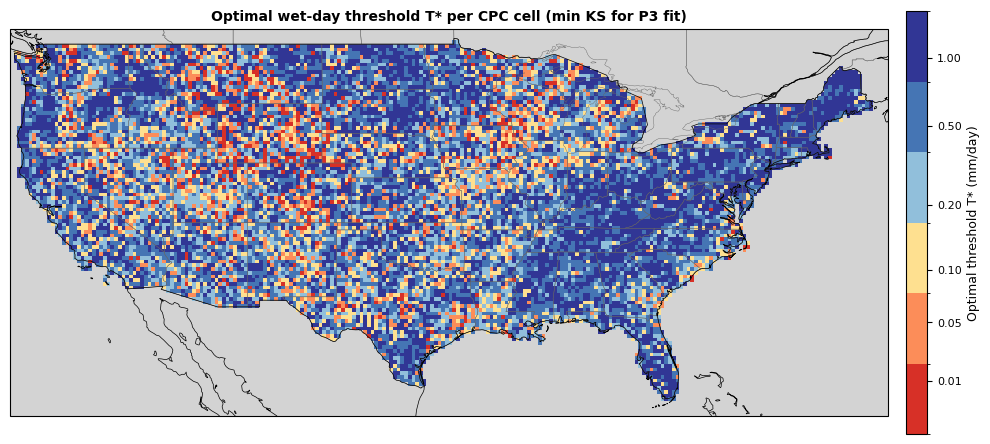

In [7]:
def _conus_ax(ax):
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='0.4')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    return ax

def map_panel(ax, lon, lat, data, cmap, vmin, vmax, title, cb_label=None, fig=None):
    cmap_ = plt.get_cmap(cmap).copy(); cmap_.set_bad('lightgrey')
    _conus_ax(ax)
    im = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                       cmap=cmap_, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9, fontweight='bold', pad=3)
    if cb_label and fig:
        plt.colorbar(im, ax=ax, orientation='vertical',
                     fraction=0.03, pad=0.02, shrink=0.85,
                     label=cb_label).ax.tick_params(labelsize=7)
    return im

lon = ds_thresh.lon.values
lat = ds_thresh.lat.values

# ── Figure A: Optimal threshold map ──────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 5),
                       subplot_kw={'projection': ccrs.PlateCarree()})

# Discrete colormap for the 6 candidate thresholds
thresh_vals = THRESHOLDS
cmap_d = mcolors.ListedColormap(['#d73027','#fc8d59','#fee090','#91bfdb','#4575b4','#313695'])
bounds = [-0.005, 0.015, 0.075, 0.15, 0.35, 0.75, 1.5]
norm_d = mcolors.BoundaryNorm(bounds, cmap_d.N)
cmap_d.set_bad('lightgrey')

_conus_ax(ax)
im = ax.pcolormesh(lon, lat, ds_thresh['optimal_threshold'].values,
                   transform=ccrs.PlateCarree(), cmap=cmap_d, norm=norm_d)
cb = plt.colorbar(im, ax=ax, orientation='vertical',
                  fraction=0.025, pad=0.02, shrink=0.9)
cb.set_ticks([0.01, 0.05, 0.1, 0.2, 0.5, 1.0])
cb.set_ticklabels(['0.01', '0.05', '0.10', '0.20', '0.50', '1.00'])
cb.set_label('Optimal threshold T* (mm/day)', fontsize=9)
cb.ax.tick_params(labelsize=8)
ax.set_title('Optimal wet-day threshold T* per CPC cell (min KS for P3 fit)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/unconditional/figures/threshold_optimal_map.png',
            dpi=150, bbox_inches='tight')
plt.show()

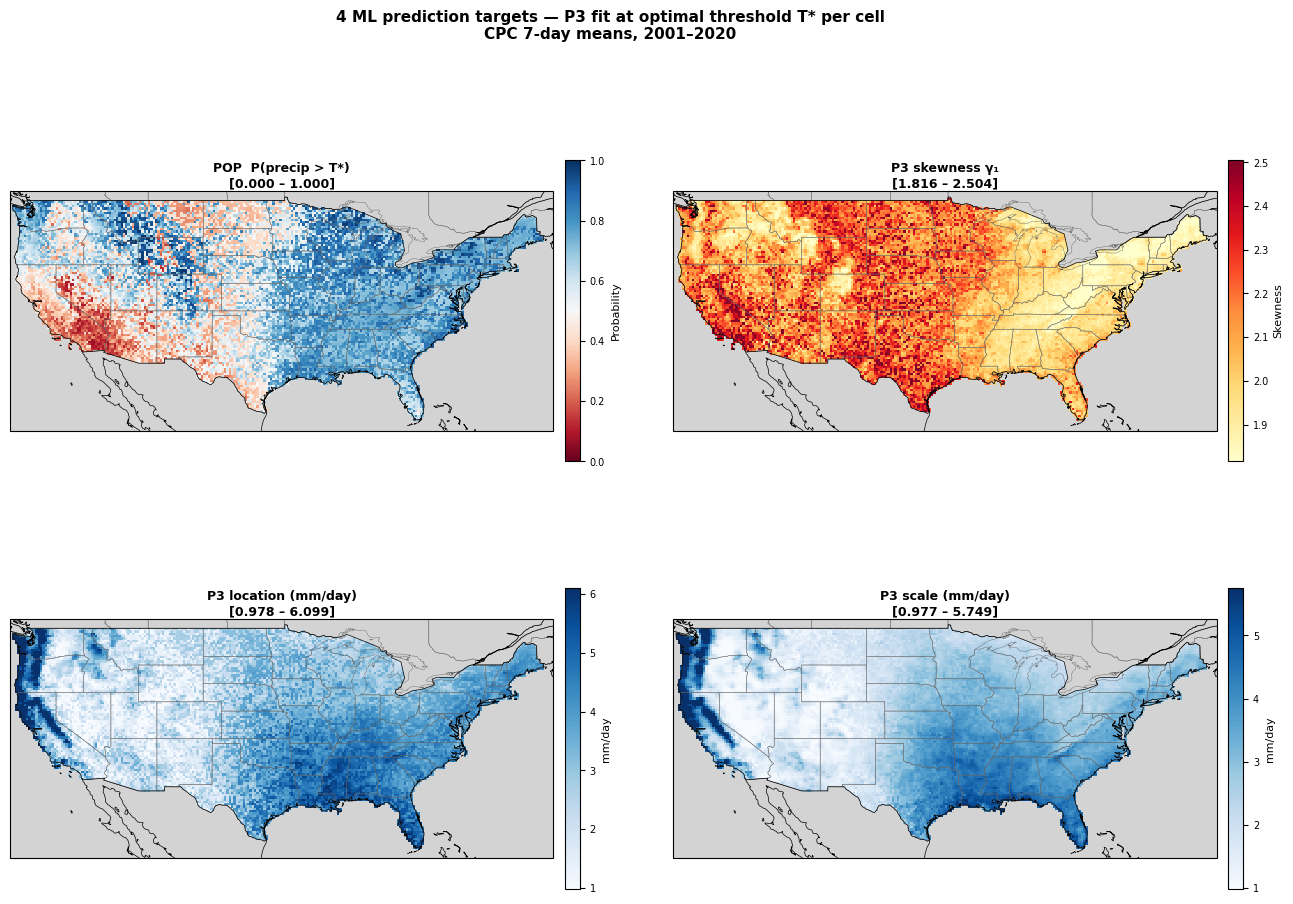

Saved: threshold_4ml_targets.png


In [8]:
# ── Figure B: 4 ML output maps (POP + P3 skew/loc/scale) ─────────────────────
# Each panel gets its own colorbar with the correct data range.
PANELS = [
    ('pop',      'POP  P(precip > T*)',  'RdBu',   0.0,  1.0,  'Probability'),
    ('p3_skew',  'P3 skewness γ₁',       'YlOrRd', None, None, 'Skewness'),
    ('p3_loc',   'P3 location (mm/day)', 'Blues',  None, None, 'mm/day'),
    ('p3_scale', 'P3 scale (mm/day)',    'Blues',  None, None, 'mm/day'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10),
                         subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=0.25, wspace=0.15)

for ax, (var, title, cmap, vmin, vmax, cb_label) in zip(axes.ravel(), PANELS):
    data = ds_thresh[var].values.copy()
    if vmin is None:
        vmin = float(np.nanpercentile(data, 2))
    if vmax is None:
        vmax = float(np.nanpercentile(data, 98))
    data_clipped = np.clip(data, vmin, vmax)

    cmap_ = plt.get_cmap(cmap).copy()
    cmap_.set_bad('lightgrey')
    _conus_ax(ax)
    im = ax.pcolormesh(lon, lat, data_clipped, transform=ccrs.PlateCarree(),
                       cmap=cmap_, vmin=vmin, vmax=vmax)

    # Per-panel colorbar placed to the right of its own axes
    cb = plt.colorbar(im, ax=ax, orientation='vertical',
                      fraction=0.038, pad=0.02, shrink=0.88)
    cb.set_label(cb_label, fontsize=8)
    cb.ax.tick_params(labelsize=7)

    ax.set_title(f'{title}\n[{vmin:.3f} – {vmax:.3f}]',
                 fontsize=9, fontweight='bold', pad=3)

fig.suptitle('4 ML prediction targets — P3 fit at optimal threshold T* per cell\n'
             'CPC 7-day means, 2001–2020',
             fontsize=11, fontweight='bold', y=1.01)
plt.savefig('../output/unconditional/figures/threshold_4ml_targets.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: threshold_4ml_targets.png')

## 5. Future plan — conditional threshold analysis

The threshold analysis above is **unconditional** (all 7305 windows pooled).

**Next steps for Phase 2:**
- Run `fit_optimal_thresholds()` stratified by season / ENSO / MJO
  (extend `src/analysis/threshold.py` to accept a `time_mask` argument, 
   mirroring the pattern in `src/analysis/conditional.py`)
- For each stratum, produce the same 4 maps: POP + P3(skew, loc, scale)
- Compare how T* changes with conditioning — e.g., in summer (JJA) the threshold
  may shift higher in the Central Plains (more convective, sharper wet/dry separation)
- The 4-output ML model will then predict these conditional distributions:
  given [SST, Z500, IVT, soil moisture, snow depth, MJO phase …] → POP + P3 params